In [33]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [34]:
from pathlib import Path
import pandas as pd

def load_mutation_grid(base_dir: str, target_name: str = "M13_best_per_iteration.csv", mutate_probs=None) -> pd.DataFrame:
    """Load and merge per-iteration CSVs across mutation probabilities."""
    if mutate_probs is None:
        mutate_probs = [
            0.0001, 0.0002, 0.0003, 0.0004,
            0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
            0.0010, 0.0011, 0.0012, 0.0013, 0.0014,
            0.0015, 0.0016, 0.0017, 0.0018, 0.0019,
            0.0020, 0.0021, 0.0022, 0.0023, 0.0024, 0.0025,
        ]

    base_dir = Path(base_dir).resolve()
    records = []

    for prob in mutate_probs:
        folder = base_dir / f"mut_{prob:.4f}".rstrip("0").rstrip(".")
        csv_path = folder / target_name
        if not csv_path.exists():
            print(f"Missing file: {csv_path}")
            continue
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:
            print(f"Failed to read {csv_path}: {exc}")
            continue
        if {"iteration", "score", "dna_seq"}.issubset(df.columns):
            df = df[["iteration", "score", "dna_seq"]].copy()
            df["mutate_prob"] = prob
            records.append(df)
        else:
            print(f"Unexpected columns in {csv_path}: {df.columns.tolist()}")

    if records:
        merged_df = (
            pd.concat(records, ignore_index=True)
            .sort_values(["mutate_prob", "iteration"])
            .reset_index(drop=True)
        )
    else:
        merged_df = pd.DataFrame(columns=["iteration", "score", "mutate_prob", "dna_seq"])

    print(f"Loaded {len(records)} mutation bins, {len(merged_df):,} rows total.")
    return merged_df

# Example usage:
# merged_df = load_mutation_grid("codon_opt_results_m12")

In [49]:
df_list = []
for i in range(1,16):
    base_dir = f"codon_opt_results_m{i}"
    target_name = f"M{i}_best_per_iteration.csv"
    merged_df = load_mutation_grid(base_dir, target_name=target_name)
    merged_df["name"] = f"M{i}"
    merged_df["n_module"] = i
    df_list.append(merged_df)
merged_df = pd.concat(df_list, ignore_index=True)


Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 rows total.
Loaded 25 mutation bins, 25,000 

In [51]:
len(merged_df[merged_df['n_module']==10].mutate_prob.unique())

25

In [52]:
largest_iteration_df = (
    merged_df.loc[merged_df.groupby(['n_module', 'mutate_prob'])['iteration'].idxmax()]
)
largest_iteration_df.reset_index(drop=True, inplace=True)
largest_iteration_df.shape

(375, 6)

In [53]:
def process_and_save_to_sheets(df: pd.DataFrame, output_file: str, group_column: str):
    """
    Group the input DataFrame by a specified column and save each group to a separate sheet in an Excel file.

    Args:
        df (pd.DataFrame): Input DataFrame containing mutation data.
        output_file (str): Path to save the processed Excel file.
        group_column (str): Column name to group the data by.
    """
    # 生成 Well Position 列（A1 到 H12）
    rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
    cols = range(1, 13)
    well_positions = [f"{row}{col}" for row in rows for col in cols]

    # 按 group_column 分组并处理每组数据
    def process_group(group_name, group_df):
        # 按 mutate_prob 排序
        group_df = group_df.sort_values(by="mutate_prob").copy()

        # 限制行数并添加 Well Position 列
        group_df = group_df.head(len(well_positions))
        group_df["Well Position"] = well_positions[: len(group_df)]

        # 创建 Name 列
        group_df["Name"] = group_df.apply(
            lambda row: f"{row['name']}_{row['mutate_prob']}_{row['iteration']}_{row['score']:.2f}", axis=1
        )

        # 创建 Sequence 列
        group_df["Sequence"] = group_df["dna_seq"]

        # 创建 5' Phosphorylation 列并留空
        group_df["5' Phosphorylation (for blunt cloning only)"] = ""

        # 选择需要的列
        output_df = group_df[
            ["Well Position", "Name", "Sequence", "5' Phosphorylation (for blunt cloning only)"]
        ]

        # 保存到对应的 sheet
        sheet_name = str(group_name)[:31]  # Excel sheet 名称最多支持 31 个字符
        output_df.to_excel(writer, index=False, sheet_name=sheet_name)

        print(f"Data for group '{group_name}' saved to sheet '{sheet_name}' in {output_file}")

    # 创建 ExcelWriter 对象
    with pd.ExcelWriter(output_file, mode='w', engine='openpyxl') as writer:
        df.groupby(group_column).apply(lambda group: process_group(group.name, group))

# Example usage:
# process_and_save_to_sheets(merged_df, "output_file.xlsx", "n_module")


In [54]:
process_and_save_to_sheets(largest_iteration_df, output_file="largest_iteration_df.xlsx", group_column="n_module")

Data for group '1' saved to sheet '1' in largest_iteration_df.xlsx
Data for group '2' saved to sheet '2' in largest_iteration_df.xlsx
Data for group '3' saved to sheet '3' in largest_iteration_df.xlsx
Data for group '4' saved to sheet '4' in largest_iteration_df.xlsx
Data for group '5' saved to sheet '5' in largest_iteration_df.xlsx
Data for group '6' saved to sheet '6' in largest_iteration_df.xlsx
Data for group '7' saved to sheet '7' in largest_iteration_df.xlsx
Data for group '8' saved to sheet '8' in largest_iteration_df.xlsx
Data for group '9' saved to sheet '9' in largest_iteration_df.xlsx
Data for group '10' saved to sheet '10' in largest_iteration_df.xlsx
Data for group '11' saved to sheet '11' in largest_iteration_df.xlsx
Data for group '12' saved to sheet '12' in largest_iteration_df.xlsx
Data for group '13' saved to sheet '13' in largest_iteration_df.xlsx
Data for group '14' saved to sheet '14' in largest_iteration_df.xlsx
Data for group '15' saved to sheet '15' in largest_i

/tmp/ipykernel_1178/548382751.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(group_column).apply(lambda group: process_group(group.name, group))


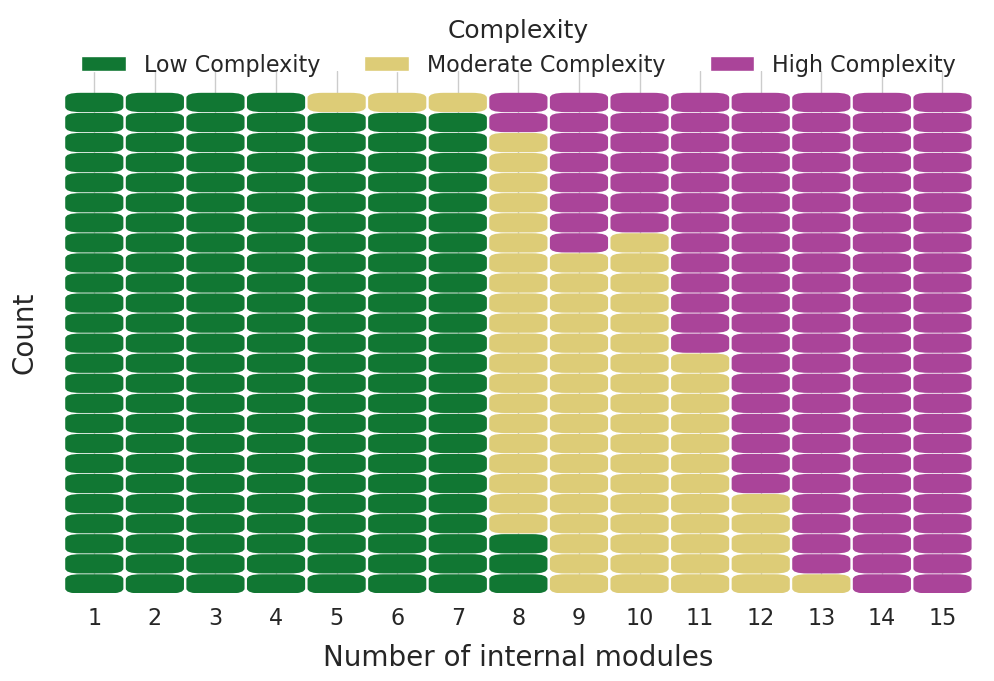

In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Updated colors
colors = {
    "Low Complexity": "#117733",
    "Moderate Complexity": "#DDCC77",
    "High Complexity": "#AA4499"
}

result_summary = {
    1:{'Low Complexity':25},
    2:{'Low Complexity':25},
    3:{'Low Complexity':25},
    4:{'Low Complexity':25},
    5:{'Low Complexity':24,'Moderate Complexity':1},
    6:{'Low Complexity':24,'Moderate Complexity':1},
    7:{'Low Complexity':24,'Moderate Complexity':1},
    8:{'Low Complexity':3,'Moderate Complexity':20,'High Complexity':2},
    9:{'Low Complexity':0,'Moderate Complexity':17,'High Complexity':8},
    10:{'Low Complexity':0,'Moderate Complexity':18,'High Complexity':7},
    11:{'Low Complexity':0,'Moderate Complexity':12,'High Complexity':13},
    12:{'Low Complexity':0,'Moderate Complexity':5,'High Complexity':20},
    13:{'Low Complexity':0,'Moderate Complexity':1,'High Complexity':24},
    14:{'Low Complexity':0,'Moderate Complexity':0,'High Complexity':25},
    15:{'Low Complexity':0,'Moderate Complexity':0,'High Complexity':25},
}

fig, ax = plt.subplots(figsize=(3*3.5,2*3.5))

rect_w, rect_h = 0.9, 0.9
radius = 0.25

for x, comp_dict in result_summary.items():
    y_offset = 0
    for comp, count in comp_dict.items():
        for _ in range(count):
            r = patches.FancyBboxPatch(
                (x - rect_w/2, y_offset),
                rect_w, rect_h,
                boxstyle=f"round,pad=0.03,rounding_size={radius}",
                linewidth=0,
                facecolor=colors[comp]
            )
            ax.add_patch(r)
            y_offset += 1

# Keep axis labels but remove axis lines + ticks
ax.set_xlim(0.3, 15.7)
ax.set_ylim(0, 26)

ax.set_xticks(list(result_summary.keys()))
ax.set_xticklabels(list(result_summary.keys()), fontsize=16)
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Number of internal modules", fontsize=20, labelpad=10)
ax.set_ylabel("Count", fontsize=20, labelpad=10)

#ax.set_title("Complexity distribution per module", fontsize=24, pad=40)

# Legend higher
legend_handles = [
    patches.FancyBboxPatch((0,0),1,1, boxstyle=f"round,pad=0.05,rounding_size={radius}", facecolor=colors[k])
    for k in colors
]

ax.legend(
    legend_handles,
    colors.keys(),
    title="Complexity",
    title_fontsize=18,
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),  # raised from 1.08 to 1.14
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("complexity_distribution.pdf", format="pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Updated colors
colors = {
    "Low Complexity": "#117733",
    "Moderate Complexity": "#DDCC77",
    "High Complexity": "#AA4499"
}

result_summary = {
    1:{'Low Complexity':25},
    2:{'Low Complexity':25},
    3:{'Low Complexity':25},
    4:{'Low Complexity':25},
    5:{'Low Complexity':24,'Moderate Complexity':1},
    6:{'Low Complexity':24,'Moderate Complexity':1},
    7:{'Low Complexity':24,'Moderate Complexity':1},
    8:{'Low Complexity':3,'Moderate Complexity':20,'High Complexity':2},
    9:{'Low Complexity':0,'Moderate Complexity':17,'High Complexity':8},
    10:{'Low Complexity':0,'Moderate Complexity':18,'High Complexity':7},
    11:{'Low Complexity':0,'Moderate Complexity':12,'High Complexity':13},
    12:{'Low Complexity':0,'Moderate Complexity':5,'High Complexity':20},
    13:{'Low Complexity':0,'Moderate Complexity':1,'High Complexity':24},
    14:{'Low Complexity':0,'Moderate Complexity':0,'High Complexity':25},
    15:{'Low Complexity':0,'Moderate Complexity':0,'High Complexity':25},
}

fig, ax = plt.subplots(figsize=(3*3.5,2*3.5))

rect_w, rect_h = 0.9, 0.9
radius = 0.25

for x, comp_dict in result_summary.items():
    y_offset = 0
    for comp, count in comp_dict.items():
        for _ in range(count):
            r = patches.FancyBboxPatch(
                (x - rect_w/2, y_offset),
                rect_w, rect_h,
                boxstyle=f"round,pad=0.03,rounding_size={radius}",
                linewidth=0,
                facecolor=colors[comp]
            )
            ax.add_patch(r)
            y_offset += 1

# Keep axis labels but remove axis lines + ticks
ax.set_xlim(0.3, 15.7)
ax.set_ylim(0, 26)

ax.set_xticks(list(result_summary.keys()))
ax.set_xticklabels(list(result_summary.keys()), fontsize=16)
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Number of internal modules", fontsize=20, labelpad=10)
ax.set_ylabel("Count", fontsize=20, labelpad=10)

#ax.set_title("Complexity distribution per module", fontsize=24, pad=40)

# Legend higher
legend_handles = [
    patches.FancyBboxPatch((0,0),1,1, boxstyle=f"round,pad=0.05,rounding_size={radius}", facecolor=colors[k])
    for k in colors
]

ax.legend(
    legend_handles,
    colors.keys(),
    title="Complexity",
    title_fontsize=18,
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),  # raised from 1.08 to 1.14
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig("complexity_distribution.pdf", format="pdf")
plt.show()


In [71]:
import math
from pathlib import Path
import pandas as pd

csv_path = Path("codon_opt_results_m8/mut_0.0001/M8_best_per_iteration.csv")
df = pd.read_csv(csv_path)
df = df.sort_values("iteration").reset_index(drop=True)

# Precompute well positions (A1-H12 = 96 wells)
rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
cols = range(1, 13)
well_positions = [f"{row}{col}" for row in rows for col in cols]

chunk_size = 50
output_file = "m8_best_per_iteration_chunks.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    num_chunks = math.ceil(len(df) / chunk_size)
    for idx in range(num_chunks):
        start = idx * chunk_size
        end = start + chunk_size
        chunk = df.iloc[start:end].copy()

        # Add required columns
        chunk = chunk.head(len(well_positions))
        chunk["Well Position"] = well_positions[: len(chunk)]
        chunk["Name"] = chunk.apply(
            lambda row: f"M8_{row['iteration']}_{row['score']:.2f}", axis=1
        )
        chunk["Sequence"] = chunk["dna_seq"]
        chunk["5' Phosphorylation (for blunt cloning only)"] = ""

        # Reorder columns for export
        export_cols = [
            "Well Position",
            "Name",
            "Sequence",
            "5' Phosphorylation (for blunt cloning only)",
        ]
        # Keep any remaining columns after the required ones
        remaining = [c for c in chunk.columns if c not in export_cols]
        chunk = chunk[export_cols + remaining]

        sheet_name = f"chunk_{idx+1}"
        chunk.to_excel(writer, index=False, sheet_name=sheet_name)

print(f"Saved {len(df)} rows into {math.ceil(len(df)/chunk_size)} sheets at {output_file}")

Saved 1000 rows into 20 sheets at m8_best_per_iteration_chunks.xlsx


In [ ]:
# 读取文件
df1 = pd.read_csv(Path("codon_opt_results_m8/mut_0.0001/M8_best_per_iteration.csv"))
df2 = pd.read_csv("well_color_iterations.csv")

# 保留前100个iteration
df1 = df1[df1['iteration'] <= 100]

# 合并两个DataFrame
merged_df = pd.merge(df1, df2, on="iteration")

# 绘制散点图
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    merged_df['iteration'], 
    merged_df['score'], 
    c=merged_df['color'], 
    cmap='viridis', 
    edgecolor='k'
)

# 添加轴标签和标题
plt.xlabel("Iteration", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.title("Scatter Plot of Iteration vs Score", fontsize=16)

# 显示图例
plt.colorbar(scatter, label="Color")

# 显示图形
plt.tight_layout()
plt.show()

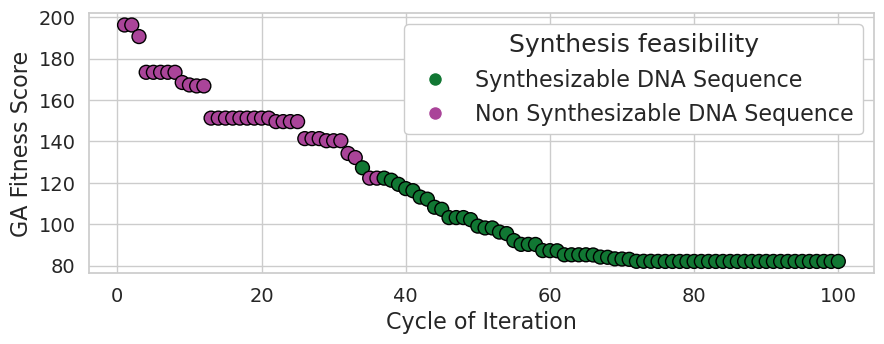

In [103]:
colors = {
    "green": "#117733",
    "yellow": "#DDCC77",
    "red": "#AA4499"
}
colors = {
    "green": "#117733",
    "yellow": "#117733",
    "red": "#AA4499"
}

# 绘制散点图
plt.figure(figsize=(3*3,1.2*3))
scatter = plt.scatter(
    merged_df['iteration'], 
    merged_df['score'], 
    c=merged_df['color'].map(colors),  # 替换颜色为colors中的值
    edgecolor='black',  # 设置点边缘颜色为黑色
    s=100  # 增大点的大小
)

# 添加轴标签
plt.xlabel("Cycle of Iteration", fontsize=16)  # 增大字体大小
plt.ylabel("GA Fitness Score", fontsize=16)  # 增大字体大小

# 设置x轴和y轴的ticks字体大小
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 删除标题
# plt.title("Scatter Plot of Iteration vs Score", fontsize=16)

complexity_labels = {
    "Synthesizable DNA Sequence":  "#117733",
    "Non Synthesizable DNA Sequence": "#AA4499"
}

# 添加图例
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
    for label, color in complexity_labels.items()
]
plt.legend(
    handles=legend_handles,
    title="Synthesis feasibility",
    title_fontsize=18,
    fontsize=16,
    loc="upper right",
    framealpha=1.0  # 设置图例背景不透明
)

# 显示图形
plt.tight_layout()
plt.savefig("scatter_plot_reduced.pdf", format="pdf")
plt.show()


In [ ]:
# Updated colors
complexity_labels = {
    "green":"Low Complexity",
    "yellow": "Moderate Complexity",
    "red": "High Complexity"
}

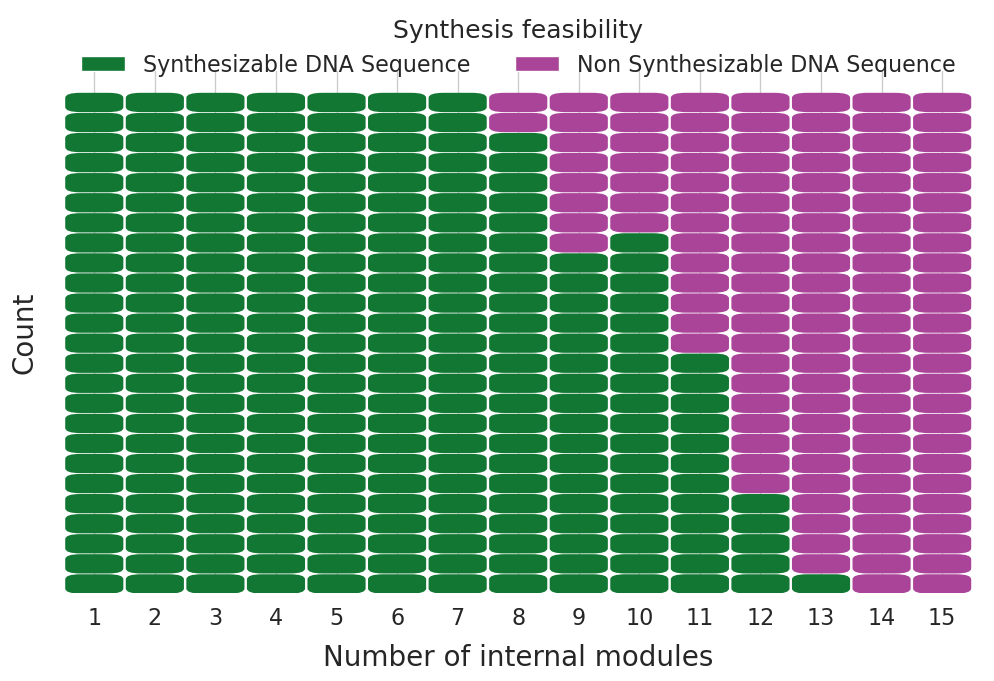

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Merge complexity buckets
colors_reduced = {
    "Synthesizable DNA Sequence": "#117733",
    "Non Synthesizable DNA Sequence": "#AA4499",
}

# Reuse result_summary defined above to build a merged summary
merged_summary = {}
for modules, comp_counts in result_summary.items():
    synth = comp_counts.get("Low Complexity", 0) + comp_counts.get("Moderate Complexity", 0)
    non_synth = comp_counts.get("High Complexity", 0)
    merged_summary[modules] = {
        "Synthesizable DNA Sequence": synth,
        "Non Synthesizable DNA Sequence": non_synth,
    }

fig, ax = plt.subplots(figsize=(3*3.5, 2*3.5))

rect_w, rect_h = 0.9, 0.9
radius = 0.25

for x, comp_dict in merged_summary.items():
    y_offset = 0
    for comp, count in comp_dict.items():
        for _ in range(count):
            r = patches.FancyBboxPatch(
                (x - rect_w/2, y_offset),
                rect_w, rect_h,
                boxstyle=f"round,pad=0.03,rounding_size={radius}",
                linewidth=0,
                facecolor=colors_reduced[comp]
            )
            ax.add_patch(r)
            y_offset += 1

ax.set_xlim(0.3, 15.7)
ax.set_ylim(0, 26)
ax.set_xticks(list(merged_summary.keys()))
ax.set_xticklabels(list(merged_summary.keys()), fontsize=16)
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Number of internal modules", fontsize=20, labelpad=10)
ax.set_ylabel("Count", fontsize=20, labelpad=10)

legend_handles = [
    patches.FancyBboxPatch((0,0),1,1, boxstyle=f"round,pad=0.05,rounding_size={radius}", facecolor=colors_reduced[k])
    for k in colors_reduced
]
ax.legend(
    legend_handles,
    colors_reduced.keys(),
    title="Synthesis feasibility",
    title_fontsize=18,
    fontsize=16,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.savefig("complexity_distribution_reduced.pdf", format="pdf")
plt.show()